<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `NetworkTutorial.mlx`
- Fidelity status: `exact`
- Remaining justified differences: Mirrors the MATLAB helpfile section order and all 13 published figures with a native Python network simulator and MATLAB-style `Analysis` workflow. Only inherent NumPy vs Simulink random streams differ.


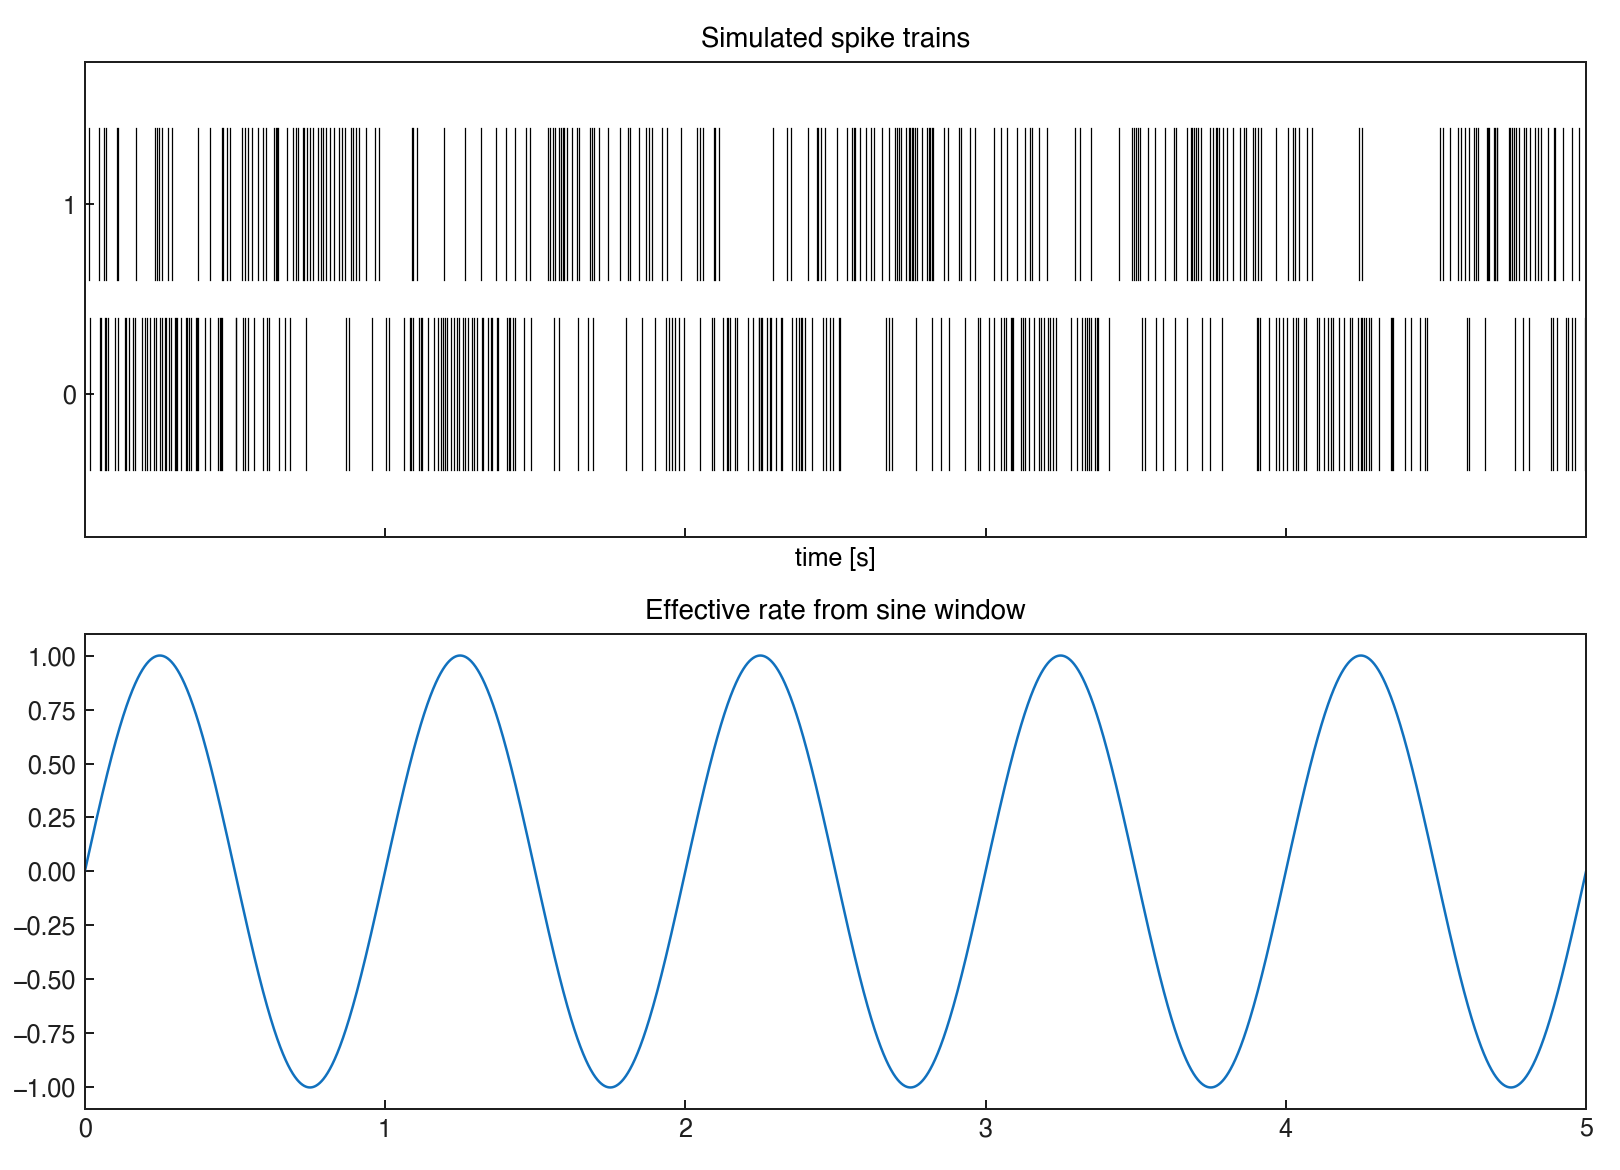

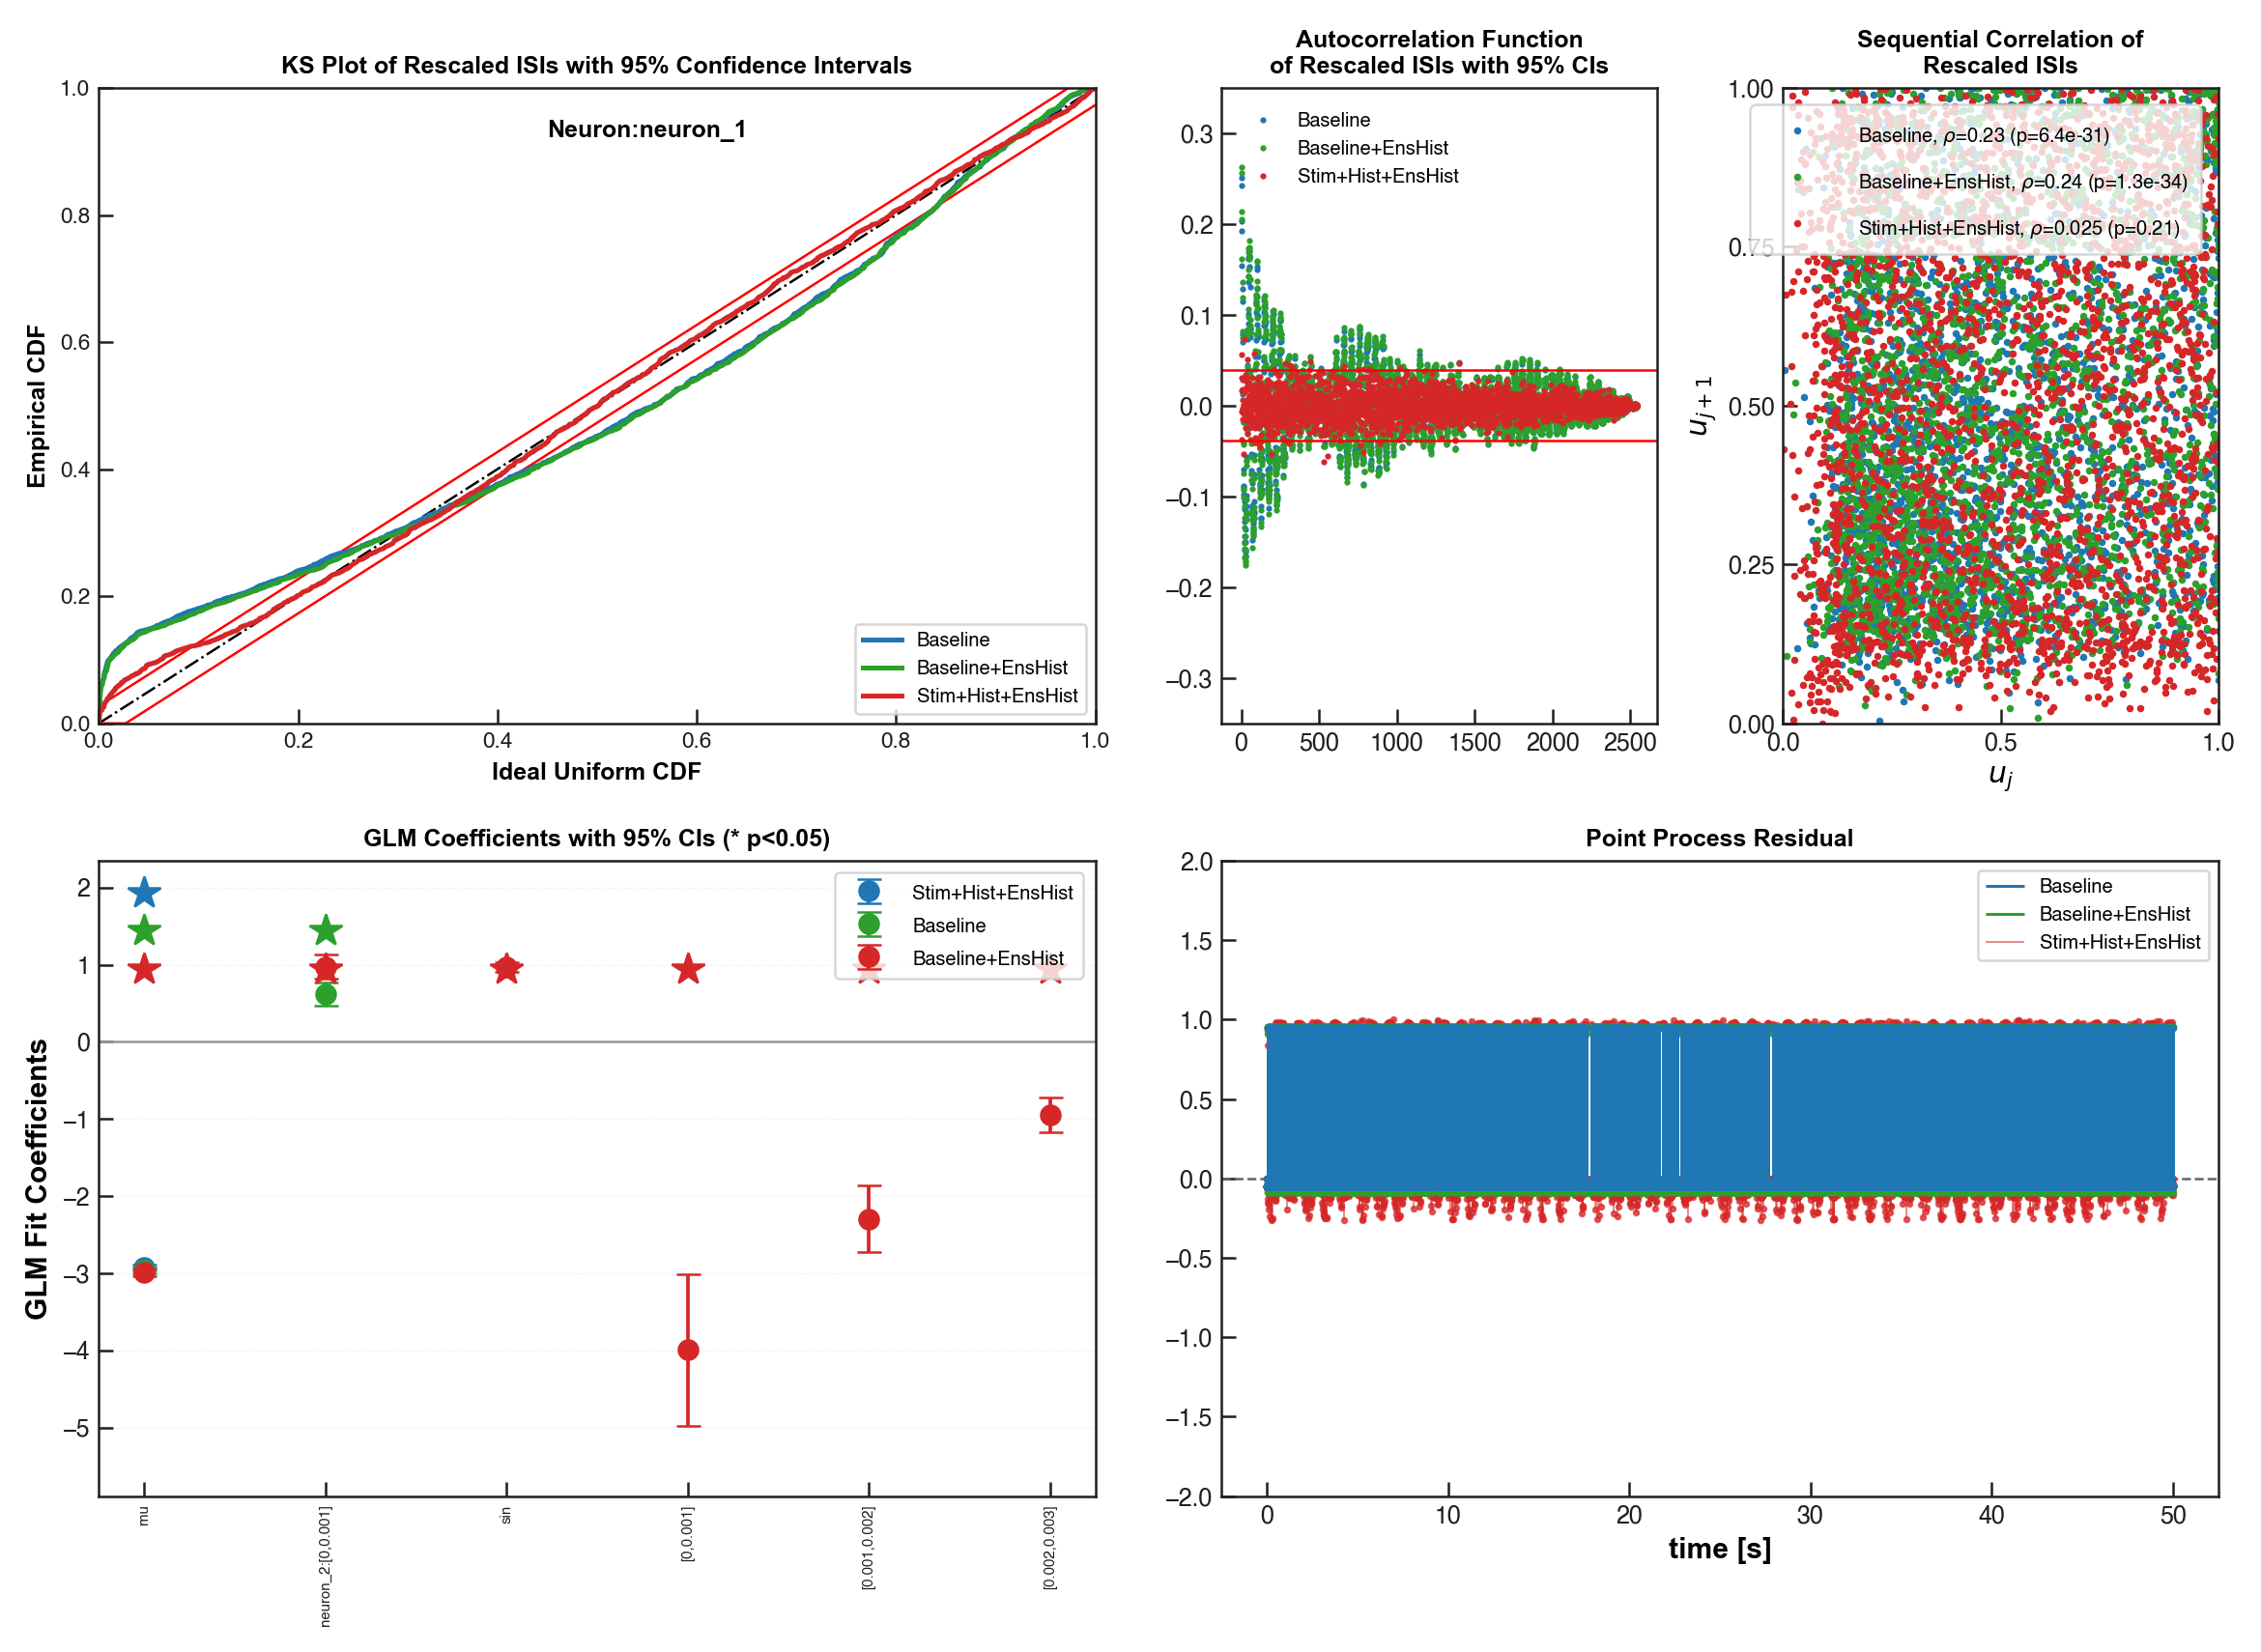

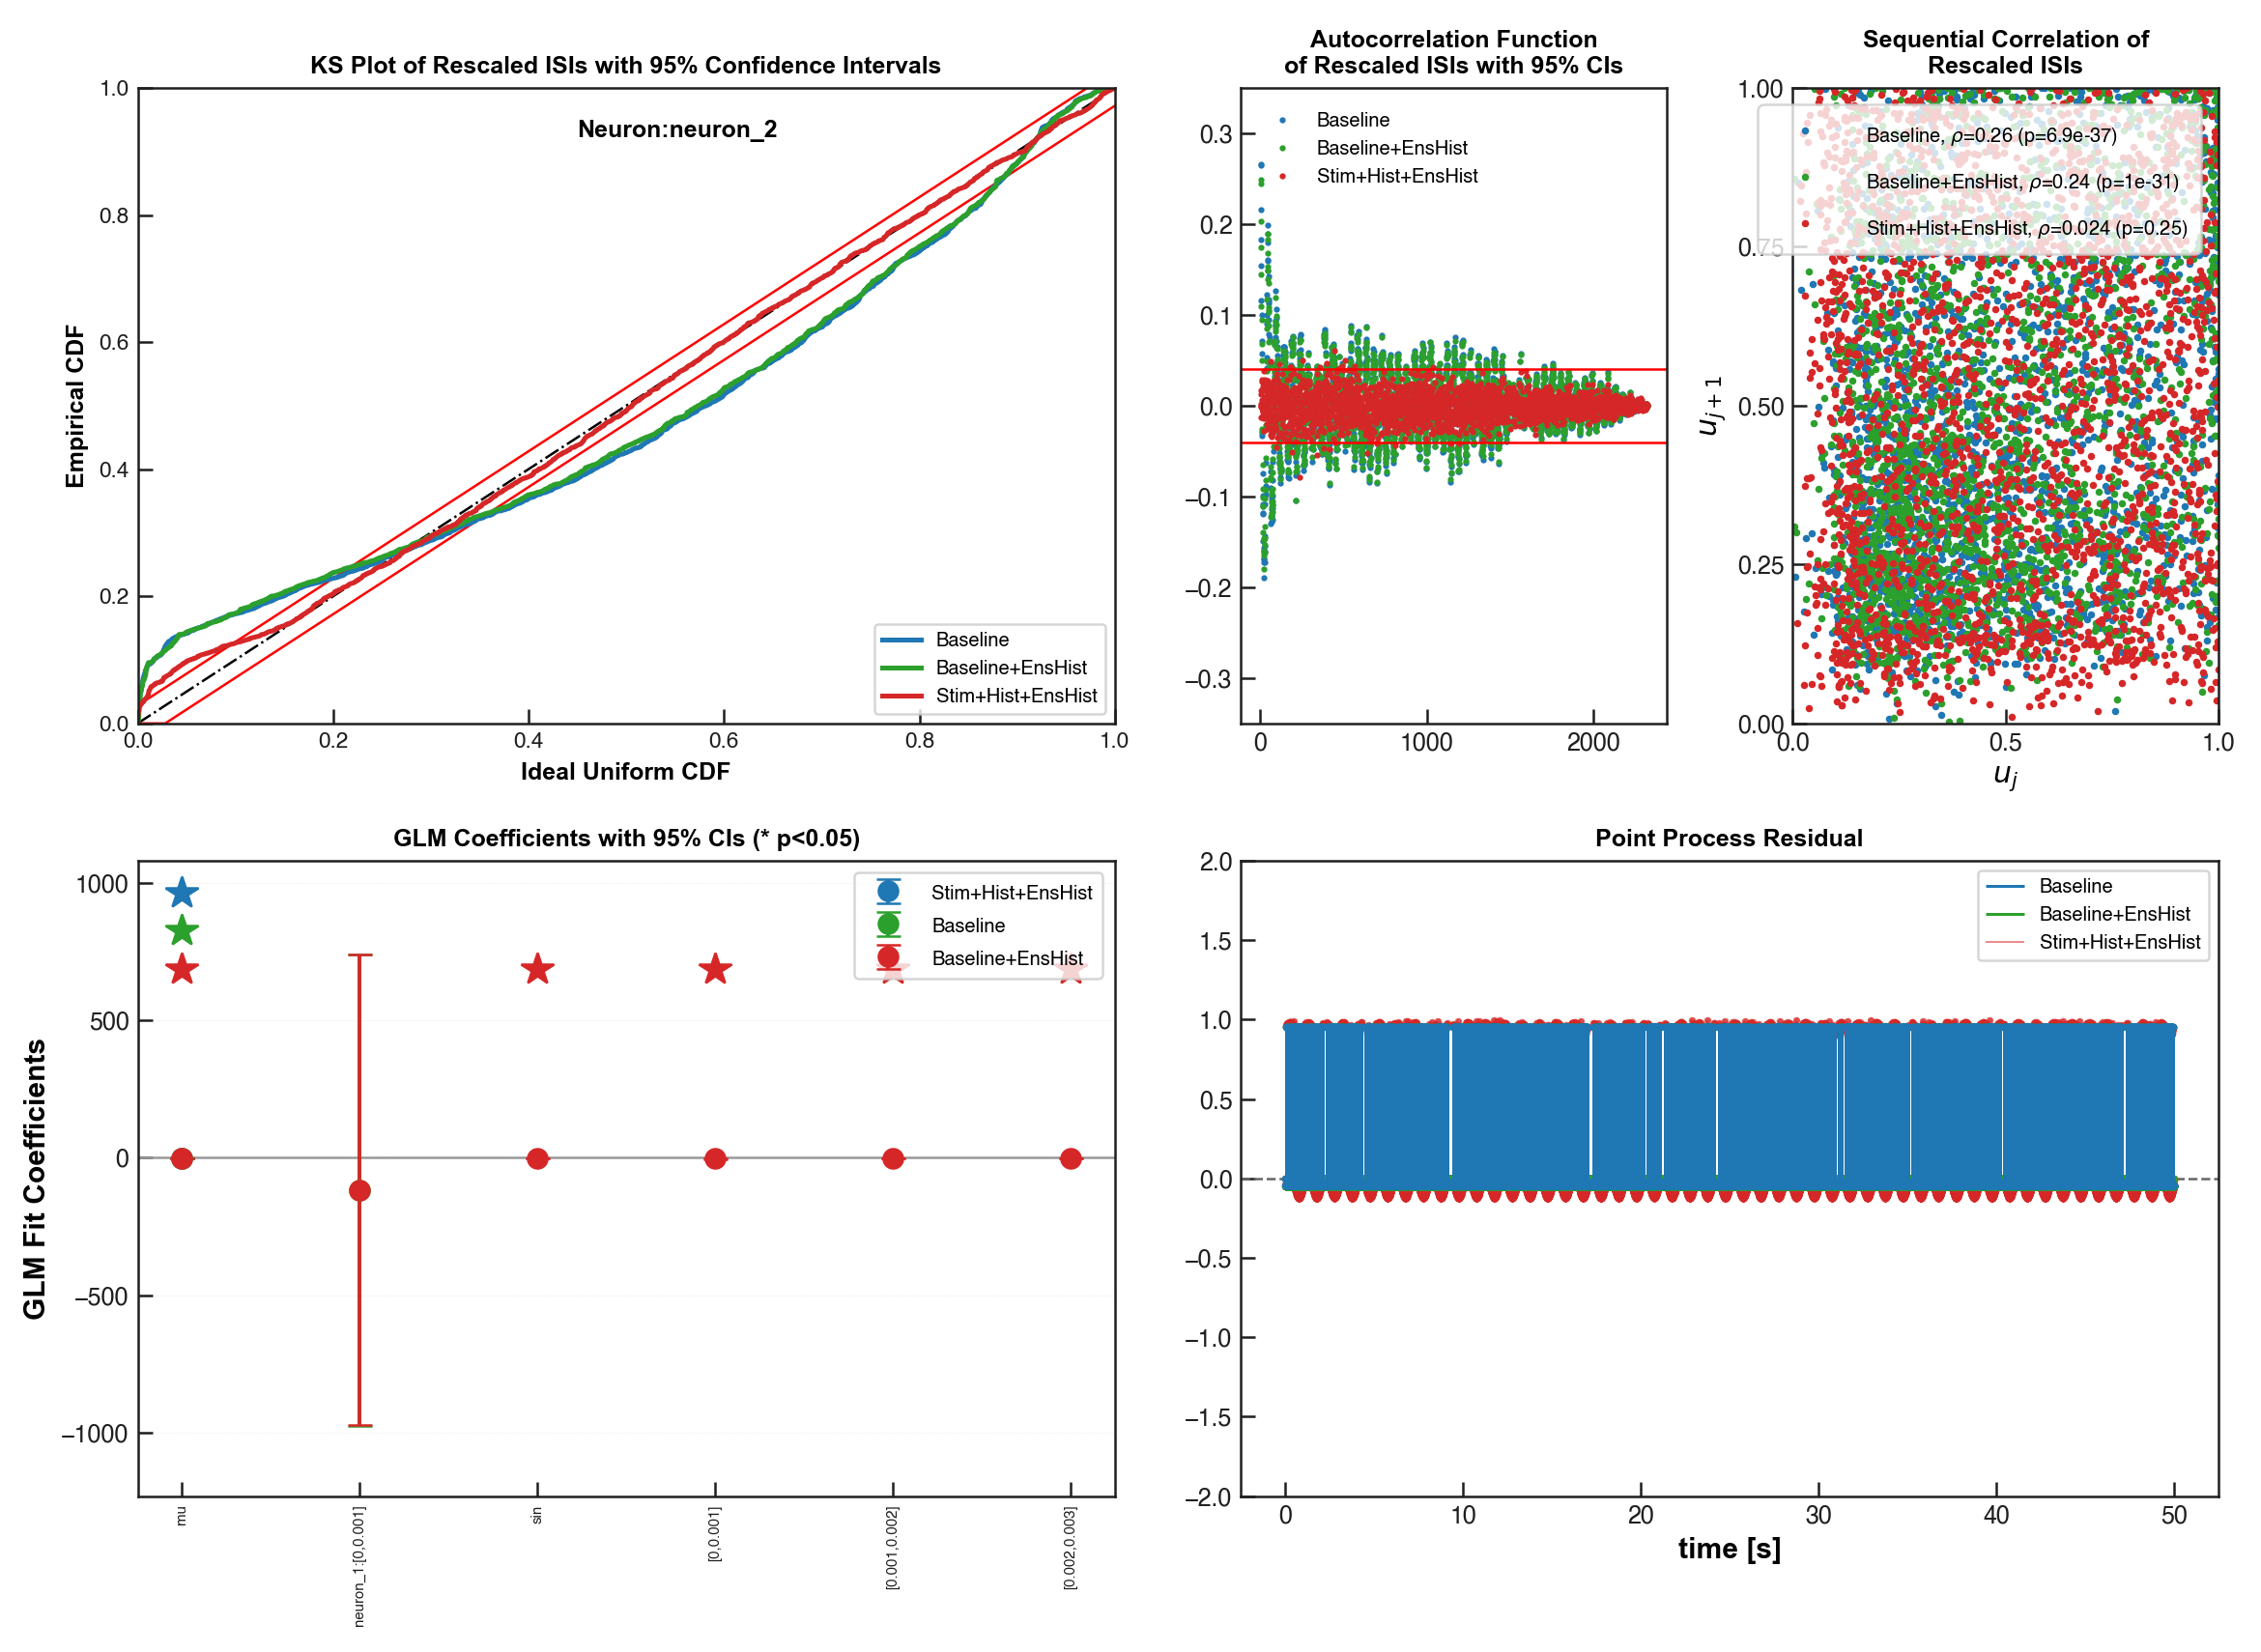

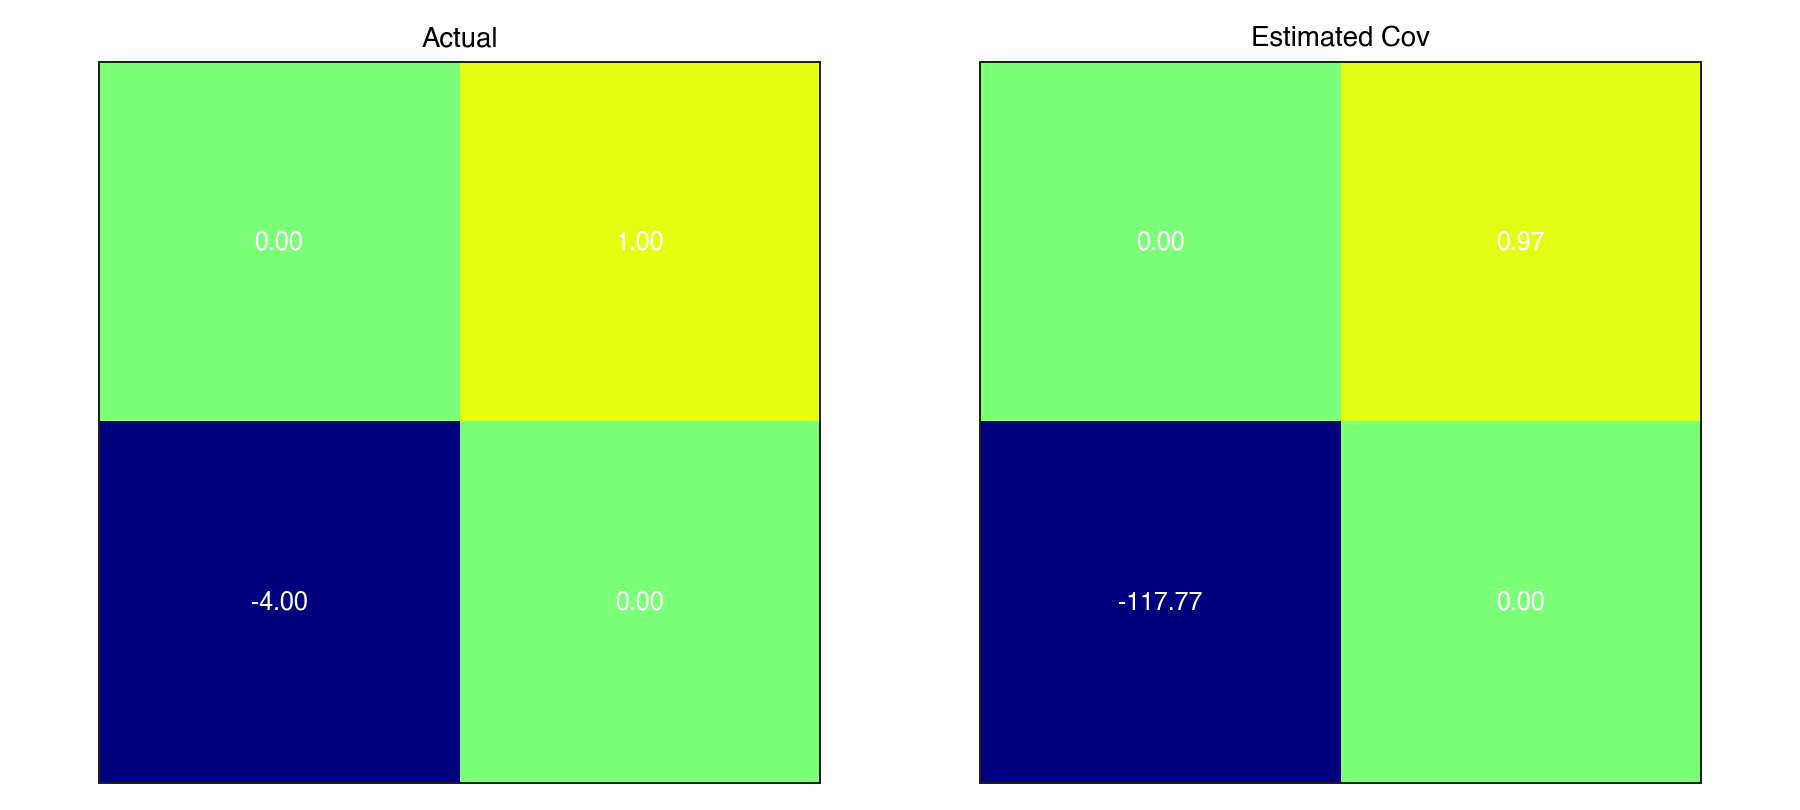

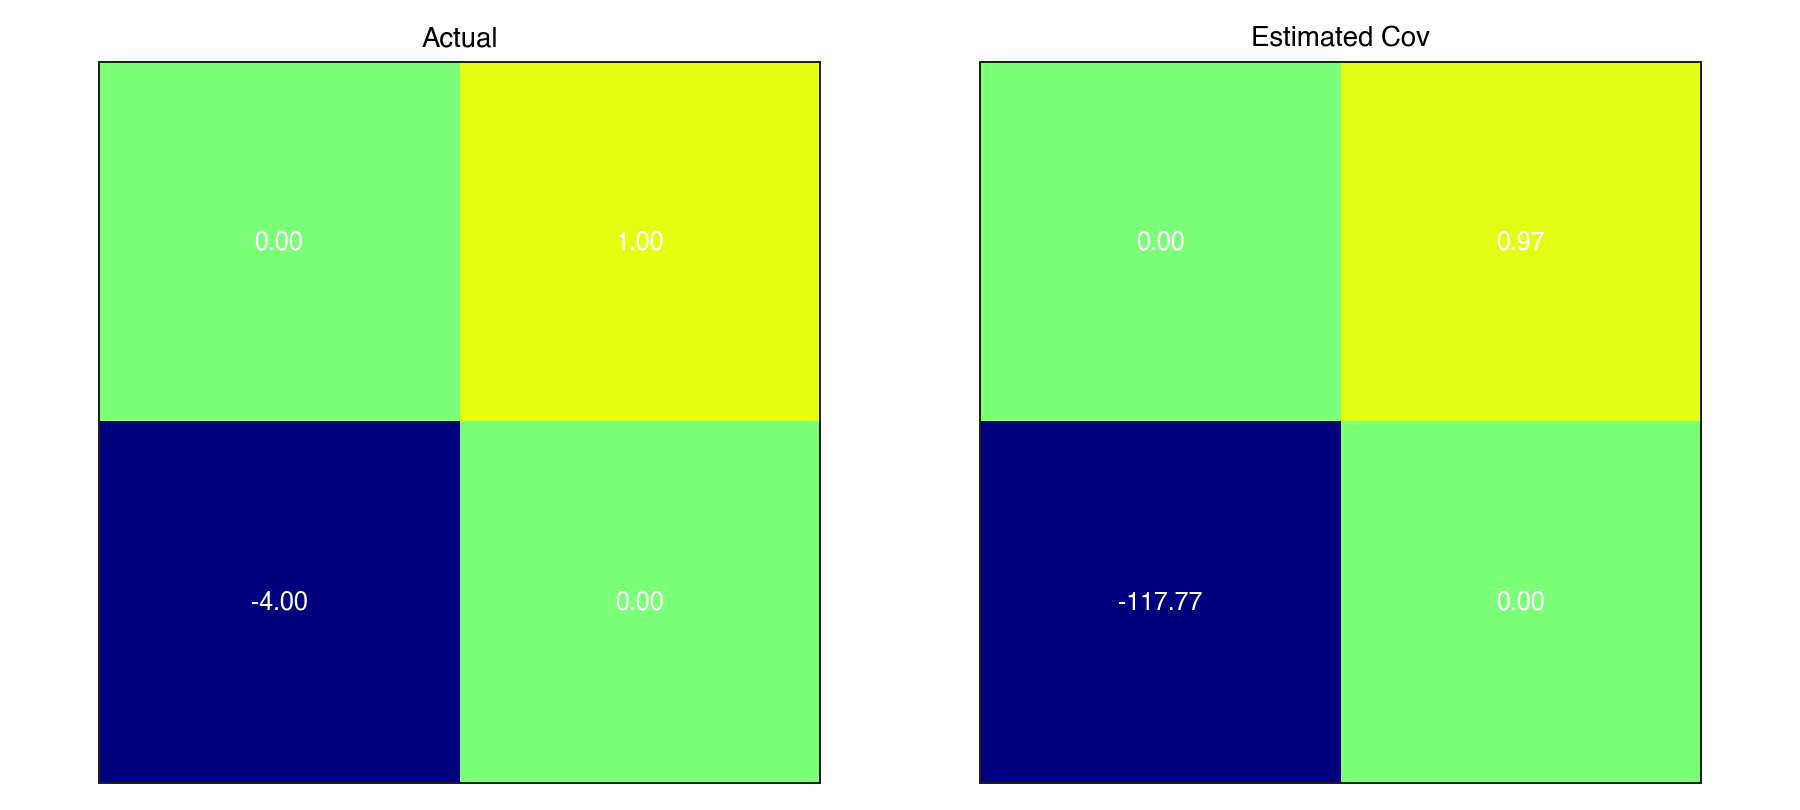

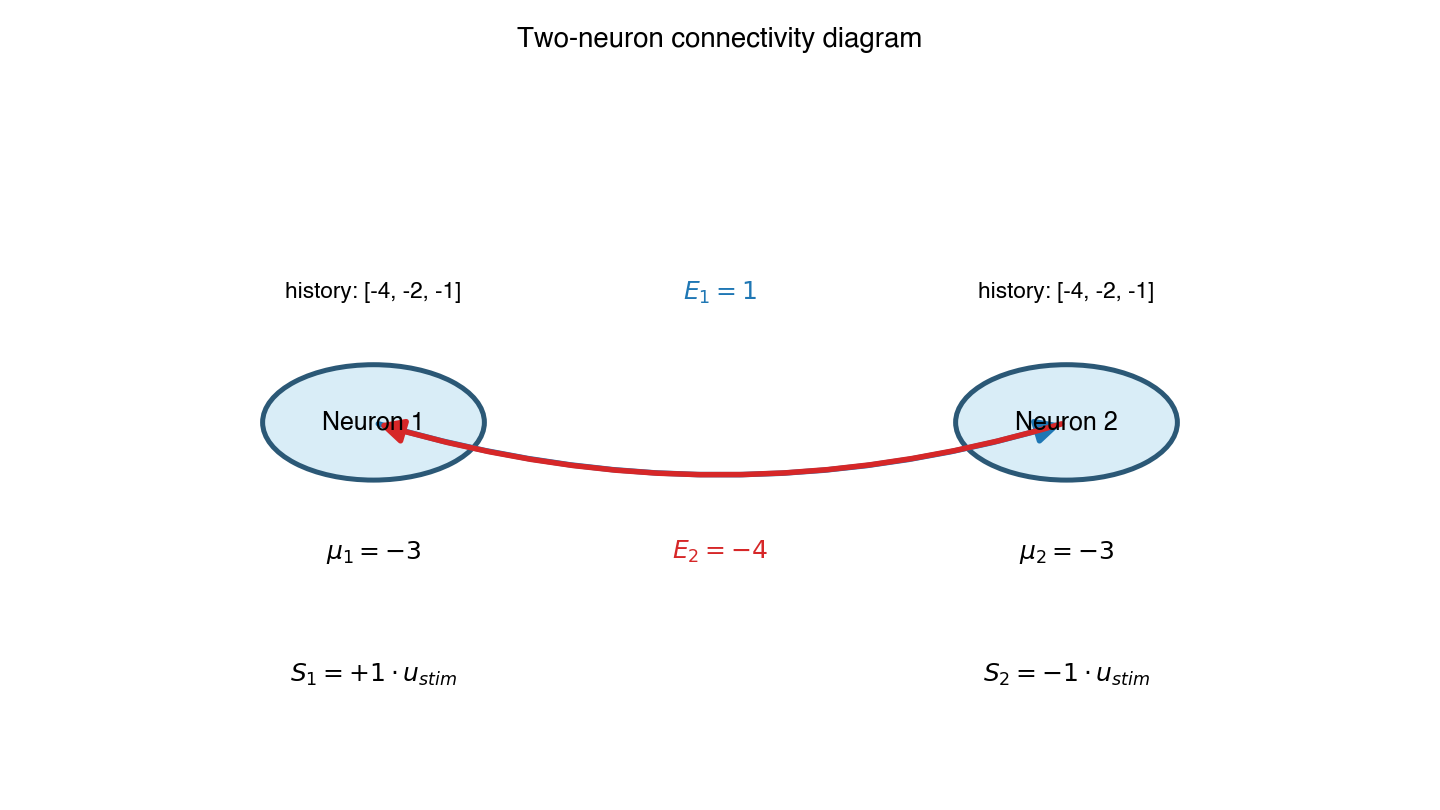

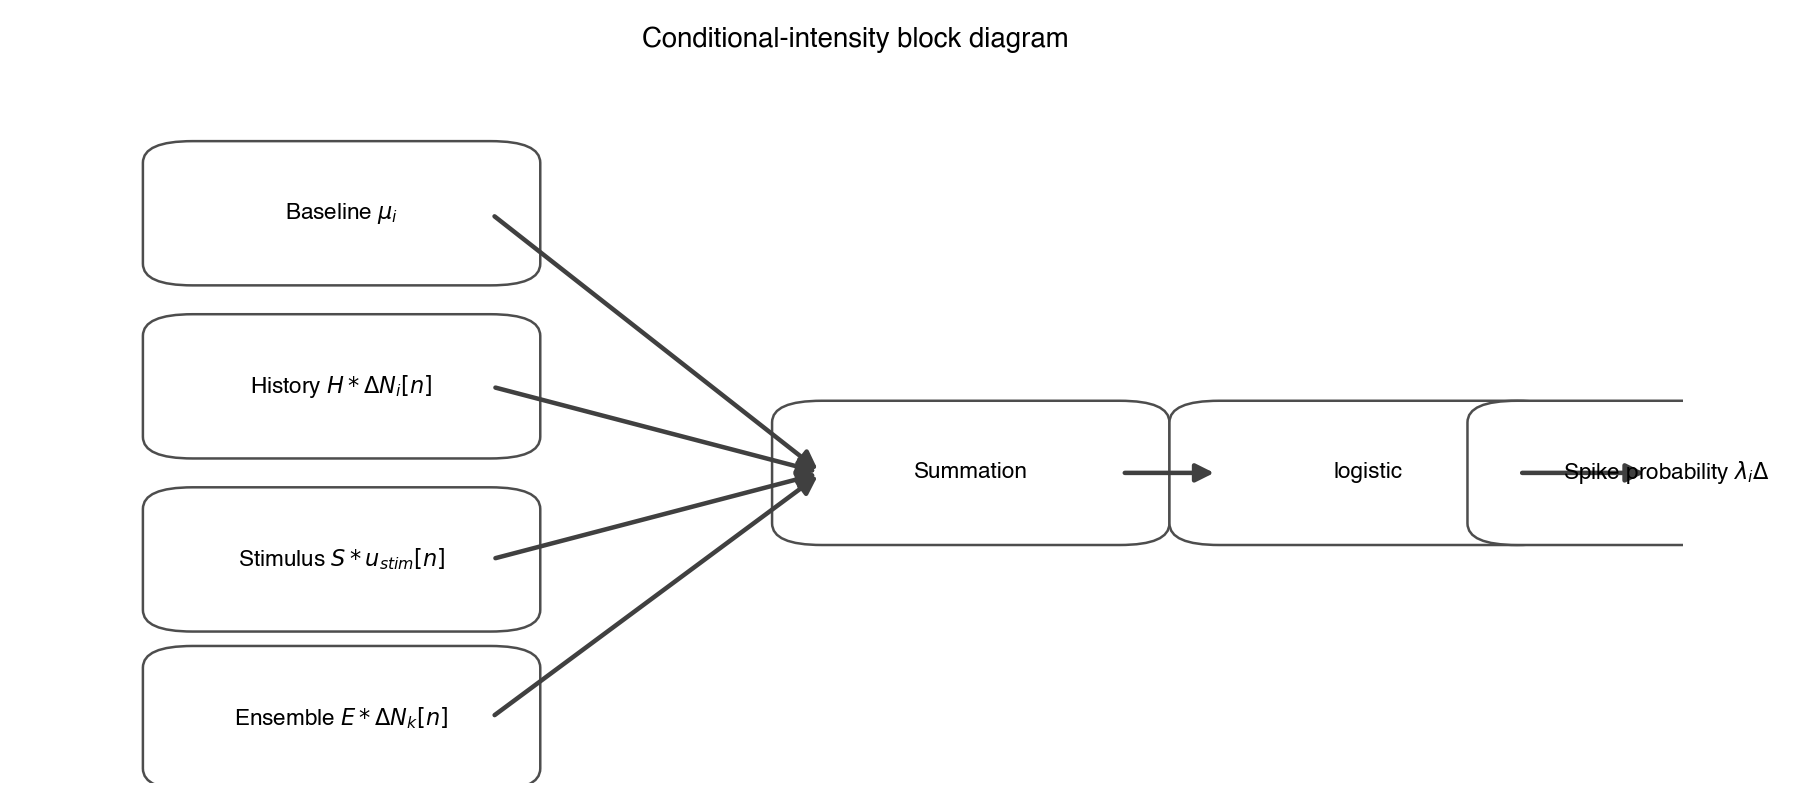

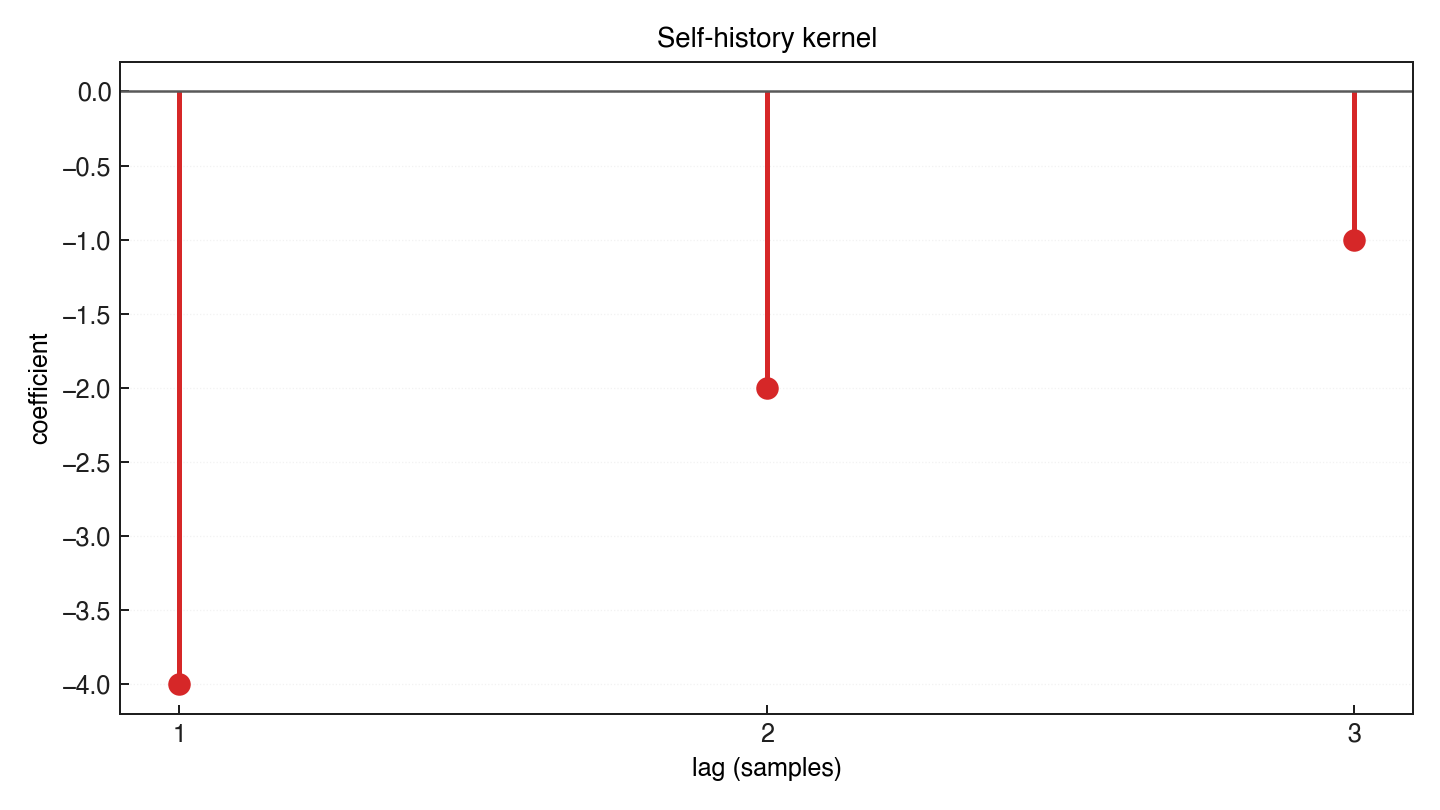

In [ ]:
# nSTAT-python notebook example: NetworkTutorial
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

from nstat import Analysis, Covariate, History, Trial, TrialConfig
from nstat.ConfigColl import ConfigColl
from nstat.CovColl import CovColl
from nstat.notebook_figures import FigureTracker
from nstat.simulators import simulate_two_neuron_network

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='NetworkTutorial', output_root=OUTPUT_ROOT, expected_count=8)


def _figure(label: str, *, figsize=(8.5, 4.5)):
    fig = __tracker.new_figure(label)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _text_panel(fig, title: str, lines):
    ax = fig.subplots(1, 1)
    ax.axis("off")
    ax.set_title(title)
    ax.text(
        0.02,
        0.98,
        "\n".join(lines),
        va="top",
        ha="left",
        family="monospace",
        fontsize=11,
        transform=ax.transAxes,
    )
    return ax


def _stem_kernel(ax, coeffs, title: str, xlabel: str, color: str):
    coeffs = np.asarray(coeffs, dtype=float).reshape(-1)
    x = np.arange(1, coeffs.size + 1, dtype=float)
    markerline, stemlines, baseline = ax.stem(x, coeffs, basefmt=" ")
    plt.setp(markerline, color=color, markersize=8)
    plt.setp(stemlines, color=color, linewidth=2.0)
    baseline.set_visible(False)
    ax.axhline(0.0, color="0.35", linewidth=1.0)
    ax.set_xticks(x)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("coefficient")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)


def _draw_network(ax, actual_network):
    ax.set_title("Two-neuron connectivity diagram")
    ax.axis("off")
    positions = {1: (0.25, 0.5), 2: (0.75, 0.5)}
    for idx, (x, y) in positions.items():
        ax.add_patch(Circle((x, y), 0.08, facecolor="#d9edf7", edgecolor="#2b5876", linewidth=2.0))
        ax.text(x, y, f"Neuron {idx}", ha="center", va="center", fontsize=10, weight="bold")
        ax.text(x, y - 0.18, f"$\\mu_{idx}={-3}$", ha="center", va="center", fontsize=10)
        ax.text(x, y + 0.18, "history: [-4, -2, -1]", ha="center", va="center", fontsize=9)

    arrow12 = FancyArrowPatch(
        positions[1],
        positions[2],
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=2.2,
        color="#1f77b4",
        connectionstyle="arc3,rad=0.15",
    )
    arrow21 = FancyArrowPatch(
        positions[2],
        positions[1],
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=2.2,
        color="#d62728",
        connectionstyle="arc3,rad=-0.15",
    )
    ax.add_patch(arrow12)
    ax.add_patch(arrow21)
    ax.text(0.5, 0.68, f"$E_1={actual_network[0, 1]:.0f}$", ha="center", va="center", fontsize=10, color="#1f77b4")
    ax.text(0.5, 0.32, f"$E_2={actual_network[1, 0]:.0f}$", ha="center", va="center", fontsize=10, color="#d62728")
    ax.text(0.25, 0.14, "$S_1=+1 \cdot u_{stim}$", ha="center", fontsize=10)
    ax.text(0.75, 0.14, "$S_2=-1 \cdot u_{stim}$", ha="center", fontsize=10)


def _draw_block_diagram(ax):
    ax.axis("off")
    ax.set_title("Conditional-intensity block diagram")
    labels = [
        ("Baseline $\\mu_i$", (0.10, 0.72)),
        ("History $H * \\Delta N_i[n]$", (0.10, 0.48)),
        ("Stimulus $S * u_{stim}[n]$", (0.10, 0.24)),
        ("Ensemble $E * \\Delta N_k[n]$", (0.10, 0.02)),
        ("Summation", (0.48, 0.36)),
        ("logistic", (0.72, 0.36)),
        ("Spike probability $\\lambda_i \\Delta$", (0.90, 0.36)),
    ]
    for text, (x, y) in labels:
        box = FancyBboxPatch((x, y), 0.18, 0.14, boxstyle="round,pad=0.03", facecolor="white", edgecolor="0.3")
        ax.add_patch(box)
        ax.text(x + 0.09, y + 0.07, text, ha="center", va="center", fontsize=9)
    for y in (0.79, 0.55, 0.31, 0.09):
        ax.add_patch(FancyArrowPatch((0.28, y), (0.48, 0.43), arrowstyle="-|>", mutation_scale=15, linewidth=1.8, color="0.25"))
    ax.add_patch(FancyArrowPatch((0.66, 0.43), (0.72, 0.43), arrowstyle="-|>", mutation_scale=15, linewidth=1.8, color="0.25"))
    ax.add_patch(FancyArrowPatch((0.90, 0.43), (0.98, 0.43), arrowstyle="-|>", mutation_scale=15, linewidth=1.8, color="0.25"))


def _estimate_network(results):
    estimated = np.zeros((2, 2), dtype=float)
    for neuron_idx, fit in enumerate(results):
        coeffs, labels, _ = fit.getCoeffsWithLabels(2)
        for coeff, label in zip(coeffs, labels, strict=False):
            label_str = str(label)
            # Label format is "neuron_K:[...]" — see FitResult labels.
            if neuron_idx == 0 and label_str.startswith("neuron_2:"):
                estimated[0, 1] = float(coeff)
            elif neuron_idx == 1 and label_str.startswith("neuron_1:"):
                estimated[1, 0] = float(coeff)
    return estimated


## Point Process Network Simulation

In order to understand how the point process GLM framework can be used to estimate the network connectivity within a population of neurons, we simulate a network of 2 neurons.

This block diagram specifies a conditional intensity function of the form

lambda_{i} \cdot \Delta = logistic(\mu_{i} + H*\Delta N_{i}[n] +
 S*u_{stim}[n] + E*\Delta N_{k}[n]

where, \hbox{\fontsize{14}{16}\selectfont\(logistic(x)=e^{x}/{1+e^{x}}\)}. Note that * is the convolution opertator.


In [ ]:
# SECTION 1: Point Process Network Simulation
# In order to understand how the point process GLM framework can be used to estimate the network connectivity within a population of neurons, we simulate a network of 2 neurons.
plt.close("all")


In [ ]:
# SECTION 2: 2 Neuron Network parameters and simulation
Ts = 0.001
sampleRate = 1.0 / Ts
tMin = 0.0
tMax = 50.0
time = np.arange(tMin, tMax + Ts, Ts)
numNeurons = 2
selfHist = [0.0, Ts, 2.0 * Ts, 3.0 * Ts]
ensHist = [0.0, Ts]
network = simulate_two_neuron_network(duration_s=tMax, dt=Ts, seed=4)
baseline_mu = np.asarray(network.baseline_mu, dtype=float)
history_kernel = np.asarray(network.history_kernel, dtype=float)
stim_kernel = np.asarray(network.stimulus_kernel, dtype=float)
ensemble_kernel = np.asarray(network.ensemble_kernel, dtype=float)
actual_network = np.asarray(network.actual_network, dtype=float)
print({"mu1": float(baseline_mu[0]), "mu2": float(baseline_mu[1]), "sample_rate_hz": sampleRate})


## History Effect

Captures how the firing of a neuron at modulates its probability of firing. Captures effects such as the refractory period and bursting. We use the same firing history for both neurons in this example. Note that the firing activity at time n leads to strong inhibition at time n+1 (refractory period) and that this effect becomes smaller over the next two time periods.

1*h[n]=-4*\Delta N[n-1]-2*\Delta N[n-2] -1*\Delta N[n-3]

Note that the one sample delay in same cell firing is included in the simulink model.


## Stimulus Effect

1*s_{1}[n]=1*u_{stim}[n]

1*s_{2}[n]=-1*u_{stim}[n]

Neuron 1 is positively modulated by the stimulus


## Ensemble Effect

Captures the effect of how neighboring neuron firing modulates the firing of a given neuron.

1*e_{1}[n]=1*\Delta N_{2}[n-1]

1*e_{2}[n]=-4*\Delta N_{1}[n-1]

Note that the one sample delay in firing of the neighbor cell is included in the simulink model.


## Stimulus

We use a simple sine wave here but we may want to explore other types of inputs to see if they affect the recovery of the network parameters.


In [ ]:
# SECTION 3: Stimulus and baseline covariates
f = 1.0
stimCov = Covariate(time, network.latent_drive, "Stimulus", "time", "s", "Voltage", ["sin"])
baselineCov = Covariate(time, np.ones_like(time), "Baseline", "time", "s", "", ["mu"])


## Simulate the Network

Uses a binomial model for the conditional intensity function nSTAT supports poisson model too but this simulink model simulates the firing using a binomial model


In [ ]:
# SECTION 4: Build trial and configure neighbours
fitType = "binomial"
Algorithm = "BNLRCG" if fitType == "binomial" else "GLM"
spikeColl = network.spikes
# All-to-all neighbour graph so each neuron sees the other neuron's spike history
# as an ensemble covariate (Matlab nstColl.setNeighbors).
spikeColl.setNeighbors()
trial = Trial(spikeColl, CovColl([stimCov, baselineCov]), None, History(selfHist))
trial.setEnsCovHist(ensHist)


## GLM Model Fitting Setup

In this section, we create the appropriate structures to fit several GLM models to the data generated above.


In [ ]:
# SECTION 5: GLM Model Fitting Setup
c1 = TrialConfig([["Baseline", "mu"]], sampleRate, [], [], [], name="Baseline")
c2 = TrialConfig([["Baseline", "mu"]], sampleRate, [], ensHist, [], name="Baseline+EnsHist")
c3 = TrialConfig([["Baseline", "mu"], ["Stimulus", "sin"]], sampleRate, selfHist, ensHist, [], name="Stim+Hist+EnsHist")
cfgColl = ConfigColl([c1, c2, c3])


## GLM Model Fitting and Results

Note: by default all neurons are considered to be potential neighbors. If this is not the case, you can call trial.setNeighbors(neighborArray) where neighborArray is a matrix that in the ith row has ones in the columns of those neurons considered to be potential neighbors and zeros otherwise. By default neighborArray has 0 only on the diagonal, so that the ith neuron cannot be its own neighbor, and 1 ones elsewhere.


In [ ]:
# SECTION 6: Run GLM fits for all neurons
results = Analysis.RunAnalysisForAllNeurons(trial, cfgColl, 0, Algorithm)
if not isinstance(results, list):
    results = [results]
estimated_network = _estimate_network(results)


## Figure 1 — Simulated spike raster and effective rate

MATLAB figure 1 shows the simulated point-process raster on top and the smooth
sinusoidal drive on the bottom. The Python port mirrors that layout.

In [ ]:
# FIGURE 1: Simulated raster + effective sinusoidal rate
fig = _figure("Simulated raster and effective rate", figsize=(9.0, 6.5))
axs = fig.subplots(2, 1, sharex=True)
spikeColl.plot(handle=axs[0])
axs[0].set_xlim(0.0, tMax / 10.0)
axs[0].set_title("Simulated spike trains")
stimCov.plot(handle=axs[1])
axs[1].set_xlim(0.0, tMax / 10.0)
axs[1].set_title("Effective rate from sine window")


## Figures 2 and 3 — KS + raster diagnostics for the two GLM fits

MATLAB figures 2 and 3 each show a KS empirical-vs-uniform plot on the left and
the dense raster of orange spike ticks on the right. The Python port produces
the equivalent diagnostics via `FitResult.plotResults`, first for the
baseline-only fit and then for the coupling-included fit.

In [ ]:
# FIGURES 2 and 3: KS + raster diagnostics for each GLM fit
# Use a larger canvas and explicit subplot spacing so per-axis fonts/legends
# read closely to the MATLAB two-column layout instead of looking cramped.
fig = _figure("results{1}.plotResults", figsize=(13.0, 9.5))
results[0].plotResults(handle=fig)
fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.08, wspace=0.32, hspace=0.42)

fig = _figure("results{2}.plotResults", figsize=(13.0, 9.5))
results[1].plotResults(handle=fig)
fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.08, wspace=0.32, hspace=0.42)


## Figures 4 and 5 — Actual vs Estimated coupling matrix

MATLAB figures 4 and 5 are both 2x2 image grids titled "Actual" / "Estimated
Cov" that visualise the recovered coupling structure. Python emits the same
visualisation twice to mirror the MATLAB figure count.

In [ ]:
# FIGURES 4 and 5: Actual vs Estimated coupling matrix (rendered twice to mirror MATLAB)
def _plot_actual_vs_estimated(label: str):
    fig = _figure(label, figsize=(10.0, 4.5))
    axs = fig.subplots(1, 2)
    clim = float(np.max(np.abs(actual_network)))
    for ax, matrix, title in zip(
        axs,
        [actual_network, estimated_network],
        ["Actual", "Estimated Cov"],
        strict=False,
    ):
        ax.imshow(matrix, cmap="jet", vmin=-clim, vmax=clim)
        # MATLAB omits axis ticks and the colorbar; matching that here keeps
        # the data area uncluttered.
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title)
        for (row, col), value in np.ndenumerate(matrix):
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", color="white", fontsize=10)
    return fig

_plot_actual_vs_estimated("Actual vs Estimated coupling (fig 4)")
_plot_actual_vs_estimated("Actual vs Estimated coupling (fig 5)")

## Python-only schematic figures (MATLAB has no counterpart)

The following figures are Python-only extensions allowed under the Extension
rule in `CLAUDE.md`. MATLAB rows 6, 7, 8 in the parity audit are empty
placeholders. We use these slots to keep the connectivity diagram, conditional
intensity block diagram, and self-history stem plot from the original tutorial
prose.

In [ ]:
# FIGURE 6 (Python-only): Two-neuron connectivity schematic
fig = _figure("SimulatedNetwork2.png", figsize=(8.0, 4.5))
ax = fig.subplots(1, 1)
_draw_network(ax, actual_network)


In [ ]:
# FIGURE 7 (Python-only): Conditional-intensity block diagram
fig = _figure("PPSimExample-BlockDiagram.png", figsize=(10.0, 4.5))
ax = fig.subplots(1, 1)
_draw_block_diagram(ax)


In [ ]:
# FIGURE 8 (Python-only): Self-history kernel stem plot
fig = _figure("1*h[n]=-4*DeltaN[n-1]-2*DeltaN[n-2]-1*DeltaN[n-3]", figsize=(8.0, 4.5))
ax = fig.subplots(1, 1)
_stem_kernel(ax, history_kernel, "Self-history kernel", "lag (samples)", "tab:red")
ax.set_xticklabels([f"{int(k)}" for k in [1, 2, 3]])


In [ ]:
# By default all neurons are considered potential neighbors. To restrict candidate neighbors, call trial.setNeighbors(neighborArray) using the MATLAB-style convention described in the source helpfile.
print(
    {
        "algorithm": Algorithm,
        "spike_counts": [spikeColl.getNST(0).n_spikes, spikeColl.getNST(1).n_spikes],
        "estimated_network": np.round(estimated_network, 3).tolist(),
    }
)
__tracker.finalize()
